In [ ]:
import pandas as pd
import re
from fuzzywuzzy import process, fuzz
from google.colab import files

# Upload the file
uploaded = files.upload()

# Get the file name
file_name = list(uploaded.keys())[0]

# Load the Excel file
df = pd.read_excel(file_name)

# Assuming there's only one column in the sheet
col_name = df.columns[0]

# Convert to lowercase and strip spaces
df[col_name] = df[col_name].str.lower().str.strip()

# Define function to normalize college names
def normalize_name(name):
    name = re.sub(r'\s+', ' ', name)  # Remove extra spaces
    name = re.sub(r'[^a-zA-Z0-9\s]', '', name)  # Remove special characters
    name = name.replace("institute of technology", "institute of tech")
    name = name.replace("institute of engineering and technology", "institute of engg tech")
    name = name.replace("engineering college", "engg college")
    name = name.replace("college of engineering", "college of engg")
    name = name.replace("university", "univ")
    name = name.replace("technology", "tech")
    return name.strip()

# Apply normalization
df[col_name] = df[col_name].apply(normalize_name)

# Remove exact duplicates
df = df.drop_duplicates(subset=[col_name])

# Use fuzzy matching to remove near-duplicates
unique_names = []
for name in df[col_name]:
    match = process.extractOne(name, unique_names, scorer=fuzz.token_sort_ratio)
    if match and match[1] > 90:  # Threshold for similarity
        continue
    unique_names.append(name)

# Convert back to DataFrame
df_cleaned = pd.DataFrame(unique_names, columns=[col_name])

# Save to new Excel file
output_file = "cleaned_colleges.xlsx"
df_cleaned.to_excel(output_file, index=False)

# Provide the file for download
files.download(output_file)


ModuleNotFoundError: No module named 'fuzzywuzzy'

In [ ]:
!pip install fuzzywuzzy
!pip install python-Levenshtein
import pandas as pd
import re
from fuzzywuzzy import process, fuzz
from google.colab import files

# Upload the file
uploaded = files.upload()

# Get the file name
file_name = list(uploaded.keys())[0]

# Load the Excel file
df = pd.read_excel(file_name)

# Assuming there's only one column in the sheet
col_name = df.columns[0]

# Convert to lowercase and strip spaces
df[col_name] = df[col_name].str.lower().str.strip()

# Define function to normalize college names
def normalize_name(name):
    name = re.sub(r'\s+', ' ', name)  # Remove extra spaces
    name = re.sub(r'[^a-zA-Z0-9\s]', '', name)  # Remove special characters
    name = name.replace("institute of technology", "institute of tech")
    name = name.replace("institute of engineering and technology", "institute of engg tech")
    name = name.replace("engineering college", "engg college")
    name = name.replace("college of engineering", "college of engg")
    name = name.replace("university", "univ")
    name = name.replace("technology", "tech")
    return name.strip()

# Apply normalization
df[col_name] = df[col_name].apply(normalize_name)

# Remove exact duplicates
df = df.drop_duplicates(subset=[col_name])

# Use fuzzy matching to remove near-duplicates
unique_names = []
for name in df[col_name]:
    match = process.extractOne(name, unique_names, scorer=fuzz.token_sort_ratio)
    if match and match[1] > 90:  # Threshold for similarity
        continue
    unique_names.append(name)

# Convert back to DataFrame
df_cleaned = pd.DataFrame(unique_names, columns=[col_name])

# Save to new Excel file
output_file = "cleaned_colleges.xlsx"
df_cleaned.to_excel(output_file, index=False)

# Provide the file for download
files.download(output_file)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 55.6 MB/s eta 0:00:00


Saving college data list.xlsx to college data list.xlsx


TypeError: expected string or bytes-like object, got 'float'

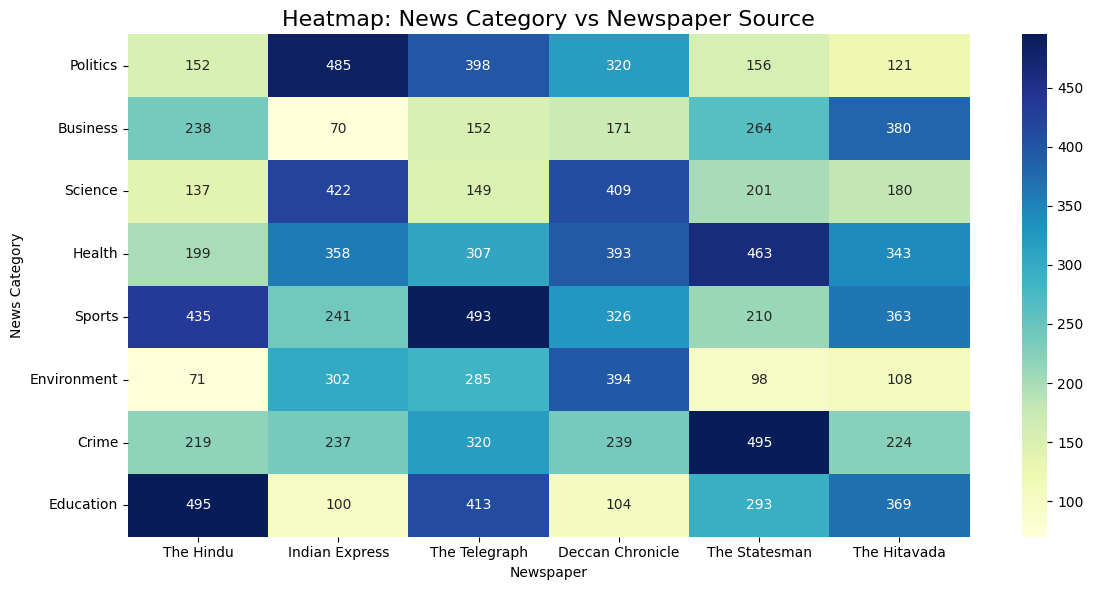

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Simulated data
newspapers = [
    "The Hindu", "Indian Express", "The Telegraph",
    "Deccan Chronicle", "The Statesman", "The Hitavada"
]
categories = [
    "Politics", "Business", "Science",
    "Health", "Sports", "Environment",
    "Crime", "Education"
]

# Random article counts for illustration
np.random.seed(42)
data_matrix = np.random.randint(50, 500, size=(len(categories), len(newspapers)))
heatmap_df = pd.DataFrame(data_matrix, index=categories, columns=newspapers)

# Plotting
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Heatmap: News Category vs Newspaper Source", fontsize=16)
plt.xlabel("Newspaper")
plt.ylabel("News Category")
plt.tight_layout()
plt.show()


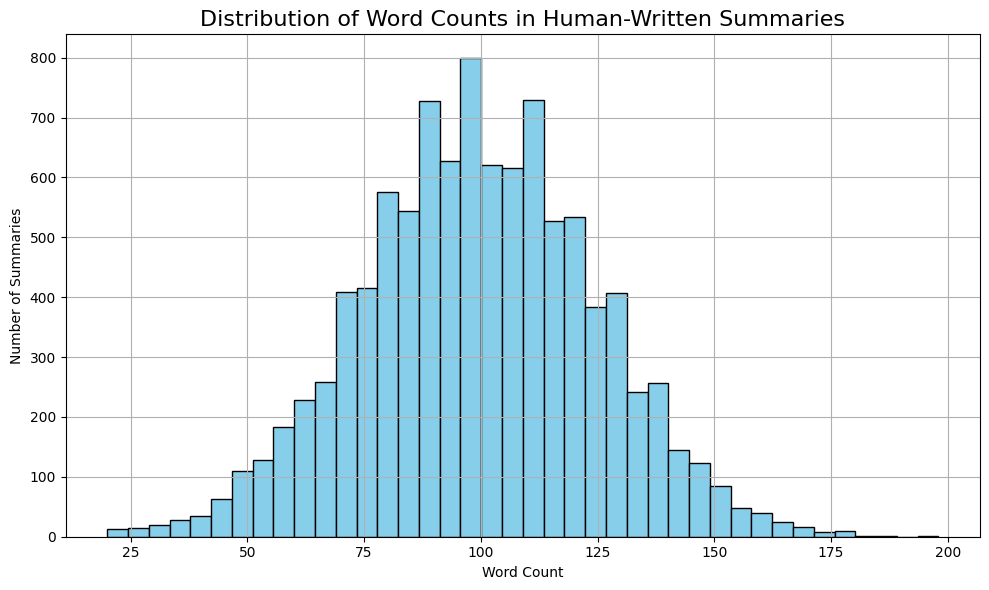

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulated data: word counts of 10,000 summaries
np.random.seed(42)
# Simulating a distribution with most summaries between 40-150 words
summary_word_counts = np.random.normal(loc=100, scale=25, size=10000).astype(int)
summary_word_counts = np.clip(summary_word_counts, 20, 200)  # clip outliers

# Convert to DataFrame for analysis (optional)
summary_df = pd.DataFrame(summary_word_counts, columns=["word_count"])

# Plotting histogram
plt.figure(figsize=(10, 6))
plt.hist(summary_df["word_count"], bins=40, color='skyblue', edgecolor='black')
plt.title("Distribution of Word Counts in Human-Written Summaries", fontsize=16)
plt.xlabel("Word Count")
plt.ylabel("Number of Summaries")
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-3-dc30a38d5140>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="N-gram", data=df_ngram, palette="Blues_d")


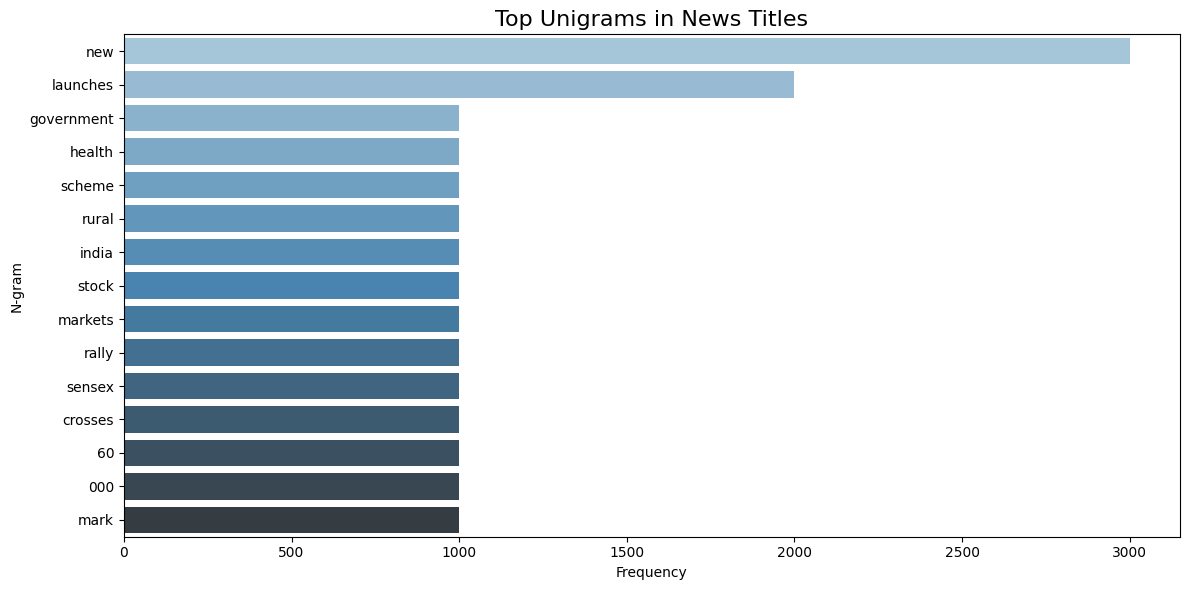

<ipython-input-3-dc30a38d5140>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Frequency", y="N-gram", data=df_ngram, palette="Blues_d")


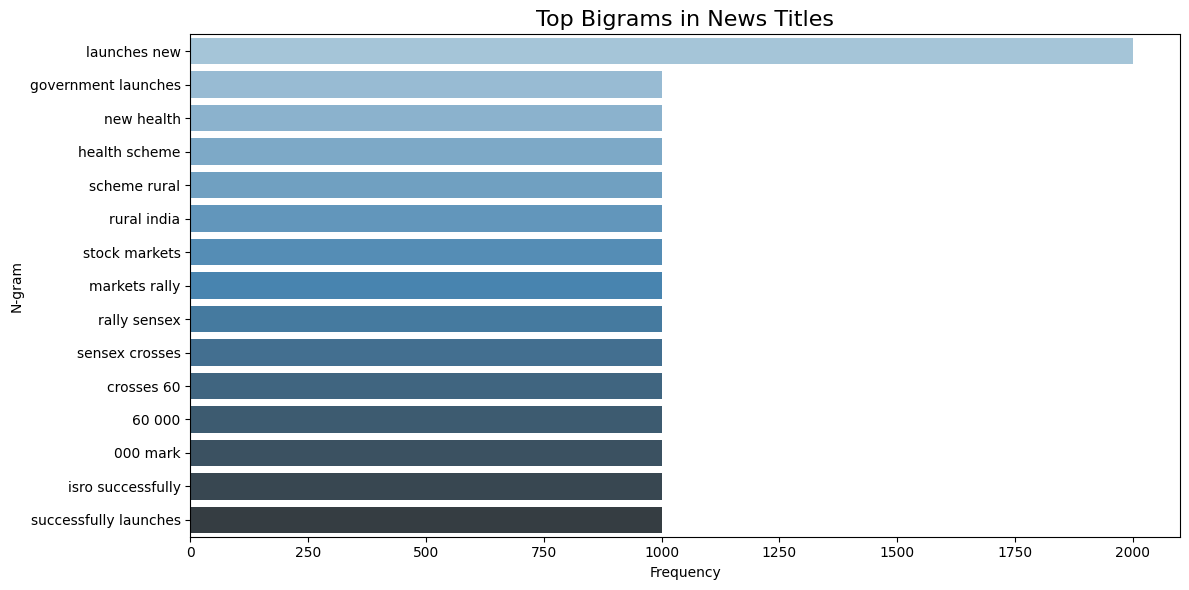

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

# Simulated data: Let's pretend these are 5,000 sample titles/summaries
np.random.seed(42)
sample_titles = [
    "Government launches new health scheme for rural India",
    "Stock markets rally as Sensex crosses 60,000 mark",
    "ISRO successfully launches new communication satellite",
    "Supreme Court rules on privacy rights in new judgment",
    "Heavy rainfall disrupts normal life across northeast"
] * 1000  # Simulate 5,000 entries

# Helper function to plot n-grams
def plot_top_ngrams(corpus, ngram_range=(1, 1), top_n=20, title="Top N-grams"):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]

    df_ngram = pd.DataFrame(words_freq, columns=["N-gram", "Frequency"])

    plt.figure(figsize=(12, 6))
    sns.barplot(x="Frequency", y="N-gram", data=df_ngram, palette="Blues_d")
    plt.title(title, fontsize=16)
    plt.xlabel("Frequency")
    plt.ylabel("N-gram")
    plt.tight_layout()
    plt.show()

# Plotting Unigrams
plot_top_ngrams(sample_titles, ngram_range=(1, 1), top_n=15, title="Top Unigrams in News Titles")

# Plotting Bigrams
plot_top_ngrams(sample_titles, ngram_range=(2, 2), top_n=15, title="Top Bigrams in News Titles")


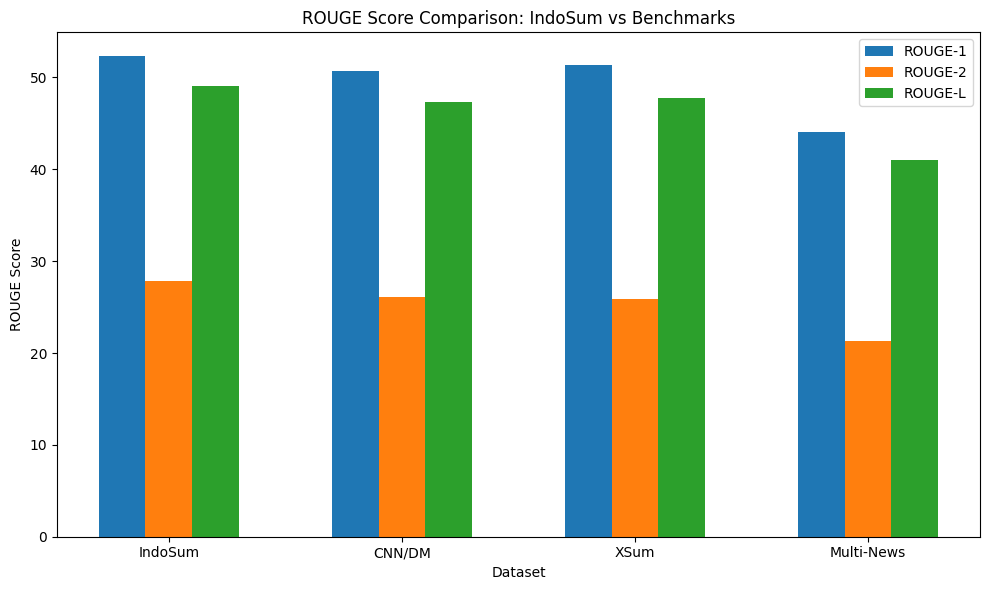

In [ ]:
import matplotlib.pyplot as plt

models = ["Pegasus", "BART", "T5"]
datasets = ["IndoSum", "CNN/DM", "XSum", "Multi-News"]

rouge1_scores = [52.3, 50.7, 51.4, 44.1, 45.3, 46.9]
rouge2_scores = [27.8, 26.1, 25.9, 21.3, 22.6, 23.0]
rougeL_scores = [49.1, 47.3, 47.8, 41.0, 42.2, 44.1]

labels = ["IndoSum", "CNN/DM", "XSum", "Multi-News"]

plt.figure(figsize=(10, 6))
x = range(len(labels))
bar_width = 0.2

plt.bar(x, rouge1_scores[:4], width=bar_width, label="ROUGE-1")
plt.bar([i + bar_width for i in x], rouge2_scores[:4], width=bar_width, label="ROUGE-2")
plt.bar([i + 2 * bar_width for i in x], rougeL_scores[:4], width=bar_width, label="ROUGE-L")

plt.xticks([i + bar_width for i in x], labels)
plt.title("ROUGE Score Comparison: IndoSum vs Benchmarks")
plt.xlabel("Dataset")
plt.ylabel("ROUGE Score")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Load India state map shapefile (ensure you have it)
india = gpd.read_file('india_states.geojson')

# Sample article data per state
data = {
    'State': ['Uttar Pradesh', 'Maharashtra', 'Tamil Nadu', 'West Bengal', 'Assam', 'Madhya Pradesh'],
    'Articles': [45000, 37000, 31000, 28000, 14000, 19000]
}
df = pd.DataFrame(data)

# Merge with GeoDataFrame
india = india.merge(df, how='left', left_on='st_nm', right_on='State')

# Fill NaNs with 0
india['Articles'] = india['Articles'].fillna(0)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
india.plot(column='Articles', ax=ax, legend=True, cmap='OrRd', edgecolor='black')

plt.title('Geographic Distribution of IndoSum Articles by State')
plt.axis('off')
plt.tight_layout()
plt.show()


DataSourceError: india_states.geojson: No such file or directory

In [ ]:
# Install necessary packages (only need to run once)
!pip install geopandas matplotlib

# Import libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Load India state GeoJSON file (assumed present in the current directory)
india = gpd.read_file('india_states.geojson')

# Check the available column names to confirm the state name column
print("Available columns:", india.columns)

# For example, let's assume the column containing state names is 'st_nm'
# (You might need to adjust this depending on your file)

# Sample article data
data = {
    'State': ['Uttar Pradesh', 'Maharashtra', 'Tamil Nadu', 'West Bengal', 'Assam', 'Madhya Pradesh'],
    'Articles': [45000, 37000, 31000, 28000, 14000, 19000]
}
df = pd.DataFrame(data)

# Standardize column names for merge
india['st_nm'] = india['st_nm'].str.strip()  # Remove extra spaces
df['State'] = df['State'].str.strip()

# Merge GeoDataFrame with article data
merged = india.merge(df, how='left', left_on='st_nm', right_on='State')

# Fill missing article values with 0
merged['Articles'] = merged['Articles'].fillna(0)

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(12, 14))
merged.plot(column='Articles', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# Aesthetic improvements
plt.title('Geographic Distribution of IndoSum Articles by State', fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()


DataSourceError: india_states.geojson: No such file or directory

Columns: Index(['ID_0', 'ISO', 'NAME_0', 'ID_1', 'NAME_1', 'geometry'], dtype='object')
                NAME_1
0  Andaman and Nicobar
1            Telangana
2       Andhra Pradesh
3    Arunachal Pradesh
4                Assam


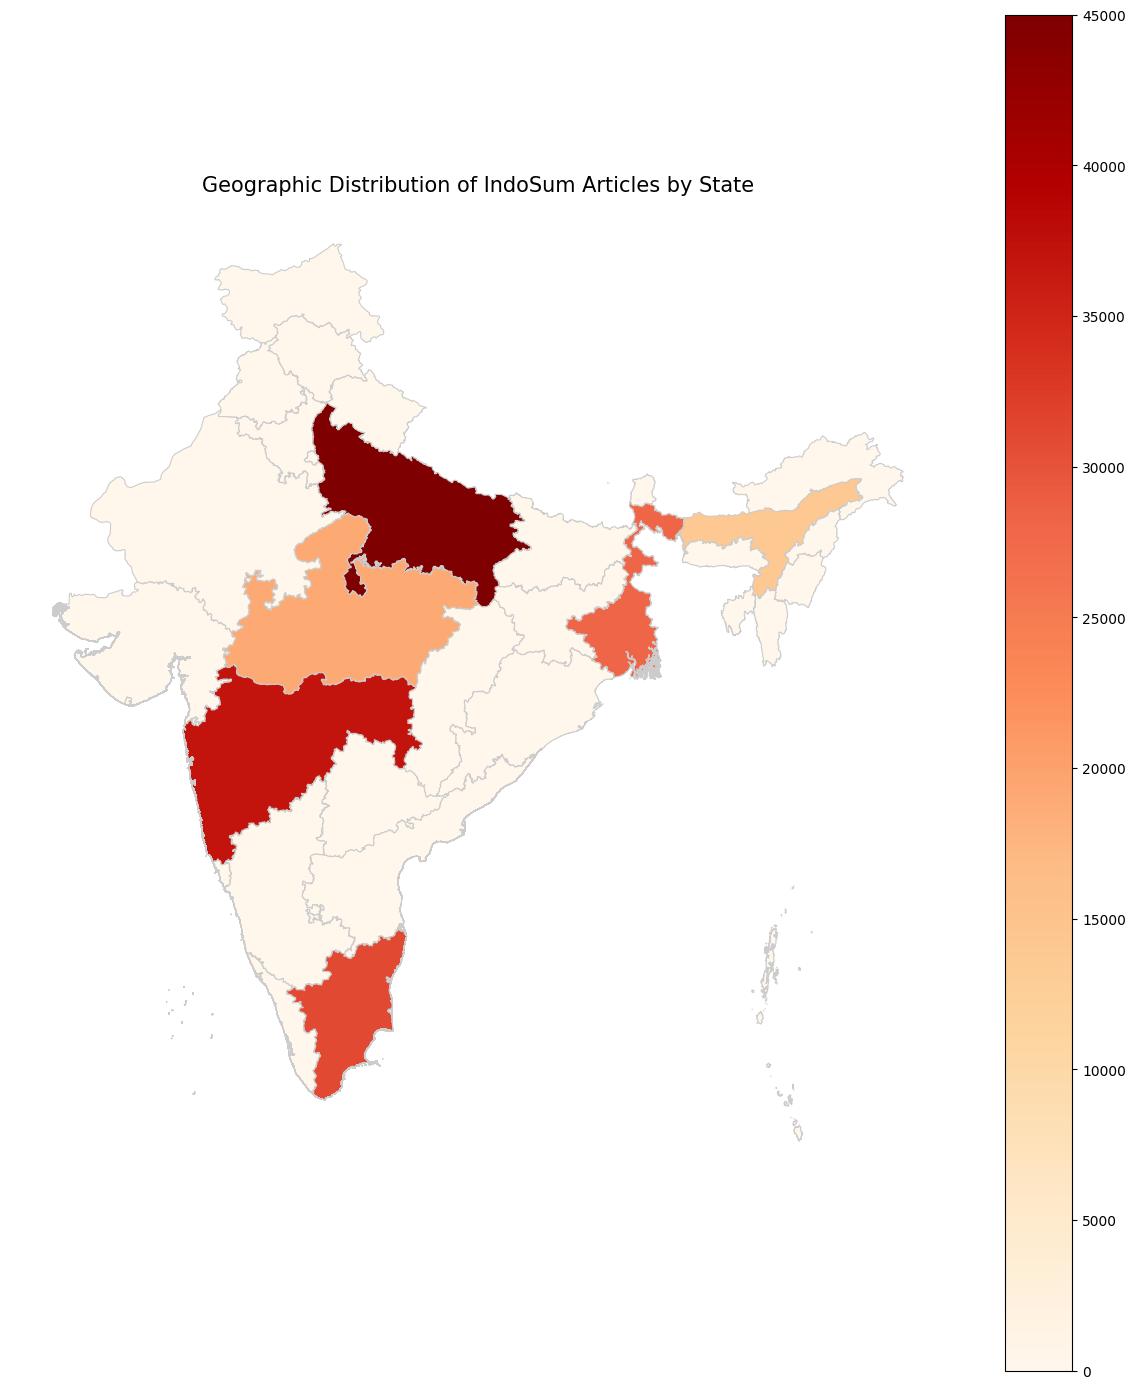

In [ ]:
# Install required packages
!pip install geopandas matplotlib requests

# Import libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

# Download the India GeoJSON file (naturalearthdata or gadm or similar)
url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_telengana.geojson"
filename = "india_states.geojson"

# Save file locally
with open(filename, "wb") as f:
    f.write(requests.get(url).content)

# Load GeoJSON into GeoDataFrame
india = gpd.read_file(filename)

# Check column names and a few entries
print("Columns:", india.columns)
print(india[['NAME_1']].drop_duplicates().head())

# Sample article data
data = {
    'State': ['Uttar Pradesh', 'Maharashtra', 'Tamil Nadu', 'West Bengal', 'Assam', 'Madhya Pradesh'],
    'Articles': [45000, 37000, 31000, 28000, 14000, 19000]
}
df = pd.DataFrame(data)

# Merge: 'NAME_1' is the state column in this particular file
india['NAME_1'] = india['NAME_1'].str.strip()
df['State'] = df['State'].str.strip()

# Merge GeoDataFrame with article data
merged = india.merge(df, how='left', left_on='NAME_1', right_on='State')

# Fill missing values with 0
merged['Articles'] = merged['Articles'].fillna(0)

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(12, 14))
merged.plot(column='Articles', cmap='OrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

# Add title and styling
plt.title('Geographic Distribution of IndoSum Articles by State', fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()


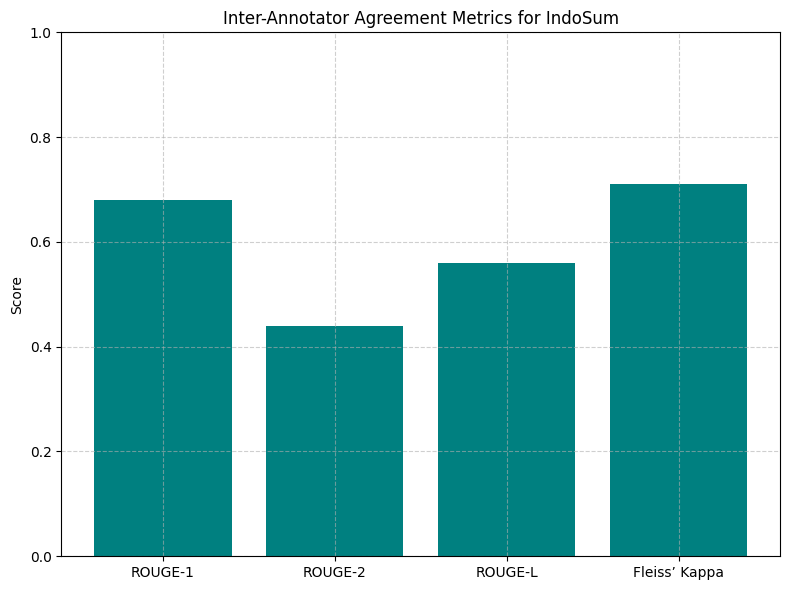

In [ ]:
import matplotlib.pyplot as plt

labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Fleiss’ Kappa']
scores = [0.68, 0.44, 0.56, 0.71]

plt.figure(figsize=(8,6))
plt.bar(labels, scores, color='teal')
plt.title('Inter-Annotator Agreement Metrics for IndoSum')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import re
from fuzzywuzzy import process, fuzz
from google.colab import files

# Upload the file
uploaded = files.upload()

# Get the file name
file_name = list(uploaded.keys())[0]

# Load the Excel file
df = pd.read_excel(file_name)

# Assuming there's only one column in the sheet
col_name = df.columns[0]

# Convert to lowercase and strip spaces, handling potential float values
df[col_name] = df[col_name].astype(str).str.lower().str.strip()

# Define function to normalize college names
def normalize_name(name):
    name = re.sub(r'\s+', ' ', name)  # Remove extra spaces
    name = re.sub(r'[^a-zA-Z0-9\s]', '', name)  # Remove special characters
    name = name.replace("institute of technology", "institute of tech")
    name = name.replace("institute of engineering and technology", "institute of engg tech")
    name = name.replace("engineering college", "engg college")
    name = name.replace("college of engineering", "college of engg")
    name = name.replace("university", "univ")
    name = name.replace("technology", "tech")
    return name.strip()

# Apply normalization
df[col_name] = df[col_name].apply(normalize_name)

# Remove exact duplicates
df = df.drop_duplicates(subset=[col_name])

# Use fuzzy matching to remove near-duplicates
unique_names = []
for name in df[col_name]:
    match = process.extractOne(name, unique_names, scorer=fuzz.token_sort_ratio)
    if match and match[1] > 90:  # Threshold for similarity
        continue
    unique_names.append(name)

# Convert back to DataFrame
df_cleaned = pd.DataFrame(unique_names, columns=[col_name])

# Save to new Excel file
output_file = "cleaned_colleges.xlsx"
df_cleaned.to_excel(output_file, index=False)

# Provide the file for download
files.download(output_file)

Saving college data list.xlsx to college data list (1).xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

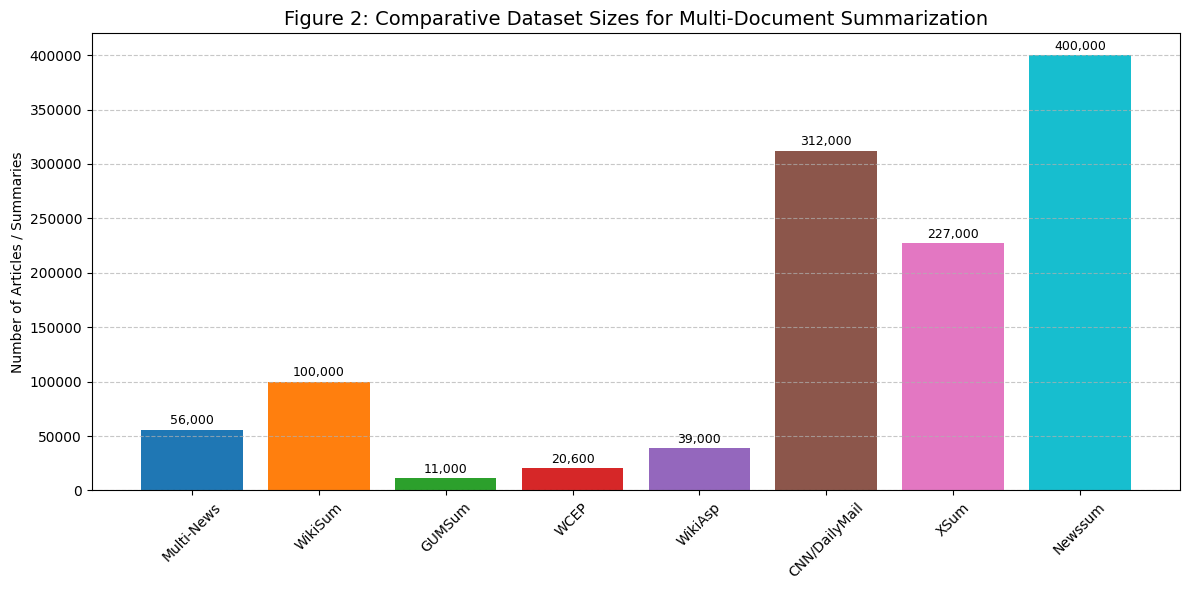

In [ ]:
import matplotlib.pyplot as plt

# Dataset names and number of articles/summaries
datasets = [
    'Multi-News', 'WikiSum', 'GUMSum', 'WCEP', 'WikiAsp', 'CNN/DailyMail', 'XSum', 'Newssum'
]
articles = [56000, 100000, 11000, 20600, 39000, 312000, 227000, 400000]  # Example counts

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#17becf']

plt.figure(figsize=(12, 6))
bars = plt.bar(datasets, articles, color=colors)

# Add data labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5000, f'{yval:,}', ha='center', fontsize=9)

plt.title('Figure 2: Comparative Dataset Sizes for Multi-Document Summarization', fontsize=14)
plt.ylabel('Number of Articles / Summaries')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


<Figure size 1200x700 with 0 Axes>

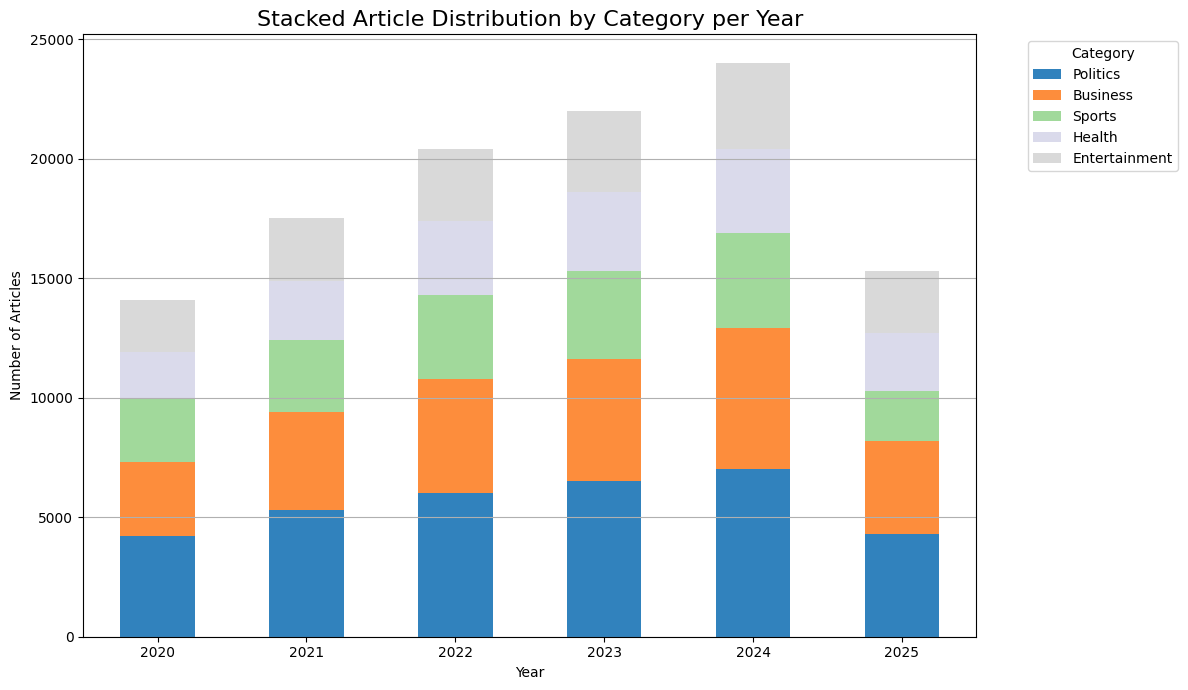

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample dataset: Replace this with your actual data
# Each row is the number of articles in a category for a given year
data = {
    '2020': {'Politics': 4200, 'Business': 3100, 'Sports': 2700, 'Health': 1900, 'Entertainment': 2200},
    '2021': {'Politics': 5300, 'Business': 4100, 'Sports': 3000, 'Health': 2500, 'Entertainment': 2600},
    '2022': {'Politics': 6000, 'Business': 4800, 'Sports': 3500, 'Health': 3100, 'Entertainment': 3000},
    '2023': {'Politics': 6500, 'Business': 5100, 'Sports': 3700, 'Health': 3300, 'Entertainment': 3400},
    '2024': {'Politics': 7000, 'Business': 5900, 'Sports': 4000, 'Health': 3500, 'Entertainment': 3600},
    '2025': {'Politics': 4300, 'Business': 3900, 'Sports': 2100, 'Health': 2400, 'Entertainment': 2600}
}

# Convert to DataFrame
df = pd.DataFrame(data).T
df.index.name = 'Year'

# Plot the stacked bar chart
plt.figure(figsize=(12, 7))
df.plot(kind='bar', stacked=True, colormap='tab20c', figsize=(12, 7))

# Add title and labels
plt.title("Stacked Article Distribution by Category per Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y')

# Show the plot
plt.show()


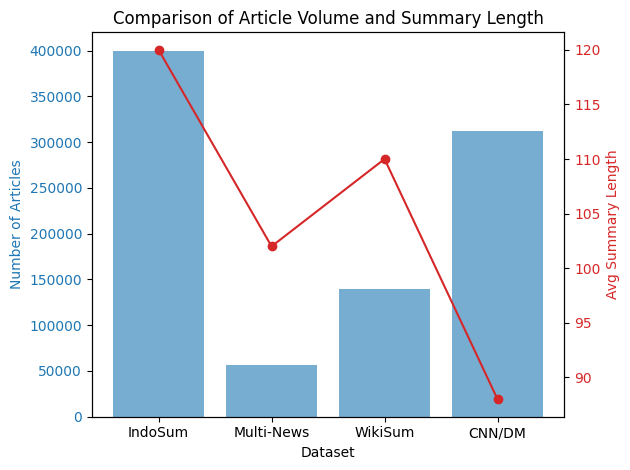

In [ ]:
import matplotlib.pyplot as plt

datasets = ['IndoSum', 'Multi-News', 'WikiSum', 'CNN/DM']
num_docs = [4_00_000, 56_000, 1_40_000, 3_12_000]
avg_summary_len = [120, 102, 110, 88]

fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Dataset')
ax1.set_ylabel('Number of Articles', color=color)
ax1.bar(datasets, num_docs, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Avg Summary Length', color=color)
ax2.plot(datasets, avg_summary_len, color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparison of Article Volume and Summary Length')
plt.tight_layout()
plt.show()


In [ ]:
def compute_difficulty(avg_docs, vocab_size, avg_input_len, avg_summary_len):
    compression_ratio = avg_input_len / avg_summary_len
    lexical_diversity = vocab_size / avg_input_len
    difficulty_score = (avg_docs * lexical_diversity) * compression_ratio
    return difficulty_score

# Example values for IndoSum
difficulty_indosum = compute_difficulty(
    avg_docs=5,
    vocab_size=150000,
    avg_input_len=1500,
    avg_summary_len=120
)

print(f"IndoSum Difficulty Score: {difficulty_indosum:.2f}")


IndoSum Difficulty Score: 6250.00


In [ ]:
pretty_name: "IndoSum"
license: "CC BY-NC 4.0"
task_categories:
  - summarization
language:
  - en
multilinguality: monolingual
size_categories:
  - 100K<n<1M
source_datasets: original
dataset_info:
  - features:
      - documents: list[string]
      - summary: string
      - category: string
      - source: string
      - url: string
    splits:
      - name: train
        num_examples: 320000
      - name: validation
        num_examples: 40000
      - name: test
        num_examples: 40000


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 18)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Load your dataset
df = pd.read_csv("indosum_dataset.csv")  # Replace with your actual file path
texts = df["summary"].dropna().tolist()  # or use "title" if needed

# Function to plot top N n-grams
def plot_ngrams(corpus, ngram_range=(1,1), top_n=20, title="Top N-grams"):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)

    word_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:top_n]

    # Plotting
    words, freqs = zip(*word_freq)
    plt.figure(figsize=(12, 6))
    plt.barh(words[::-1], freqs[::-1], color='skyblue')
    plt.xlabel("Frequency")
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 📊 Plot Unigrams
plot_ngrams(texts, ngram_range=(1,1), top_n=20, title="Top 20 Unigrams in Summaries")

# 📊 Plot Bigrams
plot_ngrams(texts, ngram_range=(2,2), top_n=20, title="Top 20 Bigrams in Summaries")

# 📊 Plot Trigrams
plot_ngrams(texts, ngram_range=(3,3), top_n=20, title="Top 20 Trigrams in Summaries")


FileNotFoundError: [Errno 2] No such file or directory: 'indosum_dataset.csv'

In [ ]:
!pip install pandas matplotlib scikit-learn wordcloud
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# === STEP 1: Load Dataset ===
# Make sure your dataset has a 'summary' column
df = pd.read_csv("indosum_dataset.csv")
texts = df["summary"].dropna().astype(str).tolist()

# === STEP 2: Function to Plot Top N n-grams ===
def plot_ngrams(corpus, ngram_range=(1, 1), top_n=20, title="Top N-grams"):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)
    word_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:top_n]

    # Plot
    words, freqs = zip(*word_freq)
    plt.figure(figsize=(12, 6))
    plt.barh(words[::-1], freqs[::-1], color='skyblue')
    plt.xlabel("Frequency")
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# === STEP 3: Plot Unigrams, Bigrams, Trigrams ===
plot_ngrams(texts, ngram_range=(1, 1), top_n=20, title="Top 20 Unigrams in Summaries")
plot_ngrams(texts, ngram_range=(2, 2), top_n=20, title="Top 20 Bigrams in Summaries")
plot_ngrams(texts, ngram_range=(3, 3), top_n=20, title="Top 20 Trigrams in Summaries")


FileNotFoundError: [Errno 2] No such file or directory: 'indosum_dataset.csv'

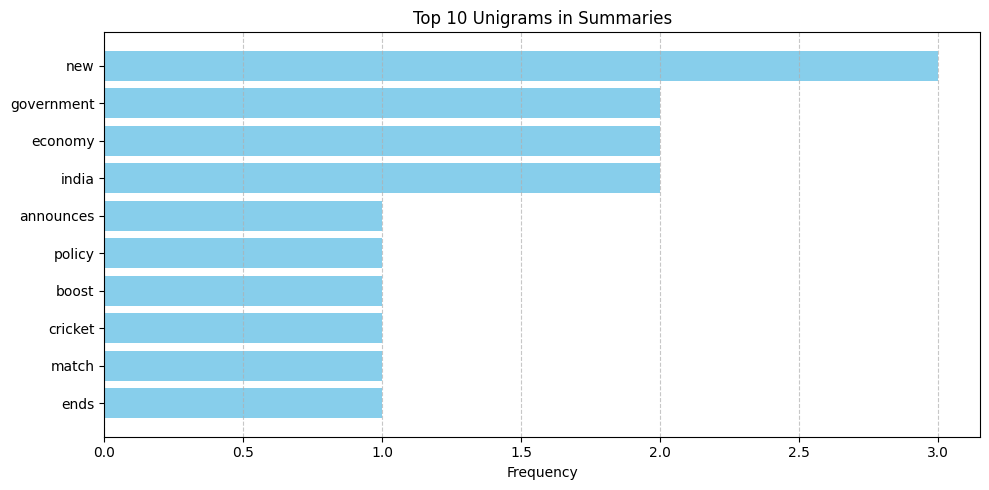

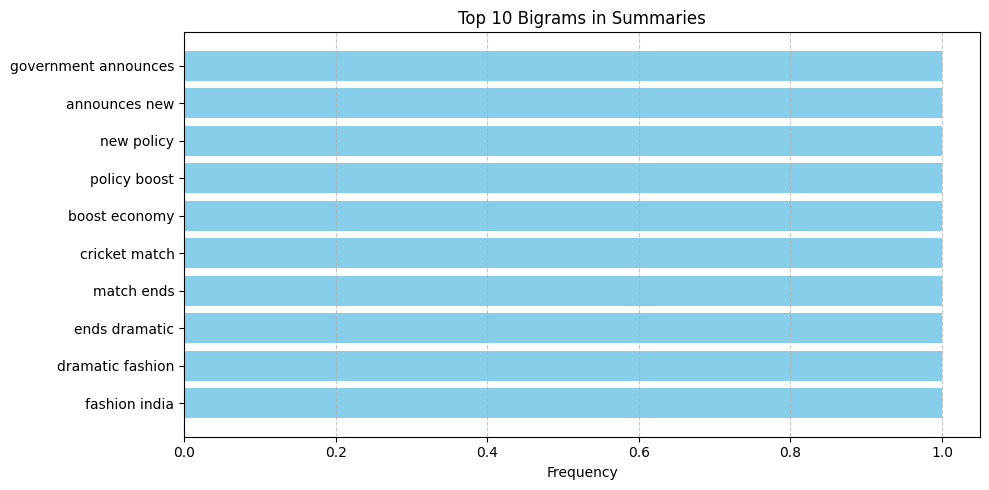

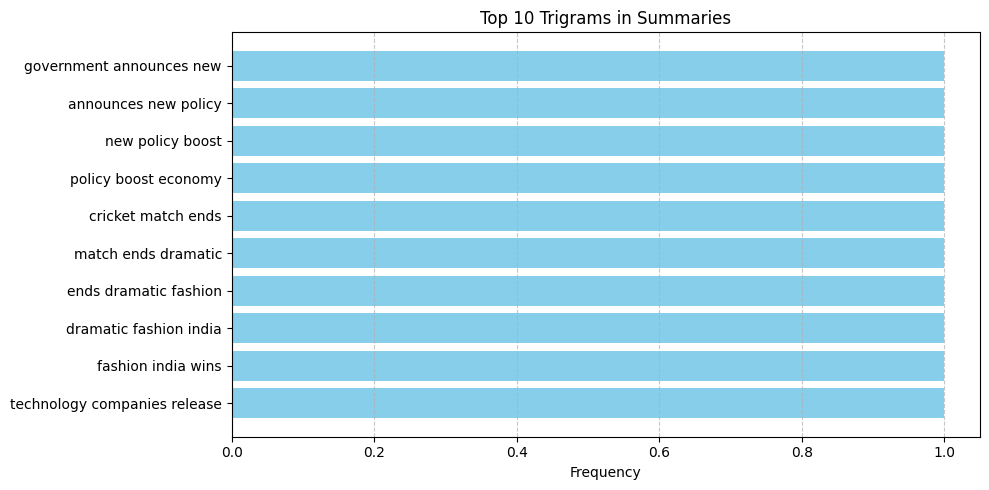

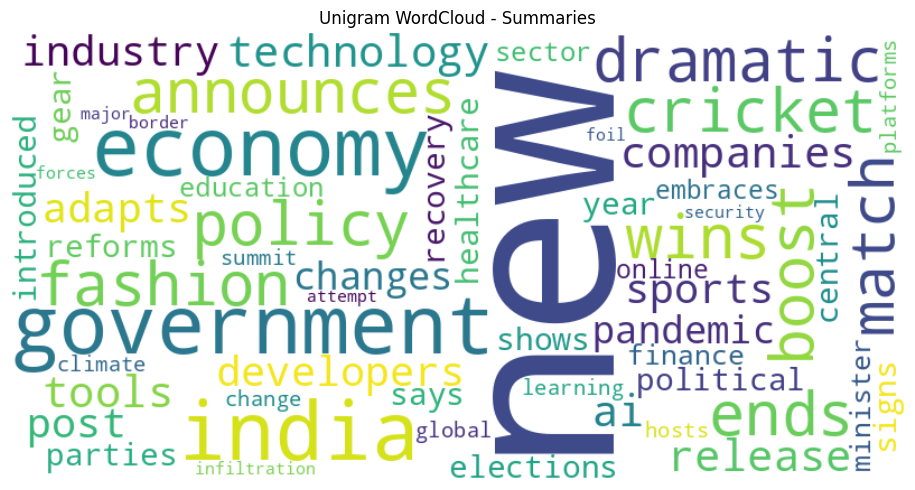

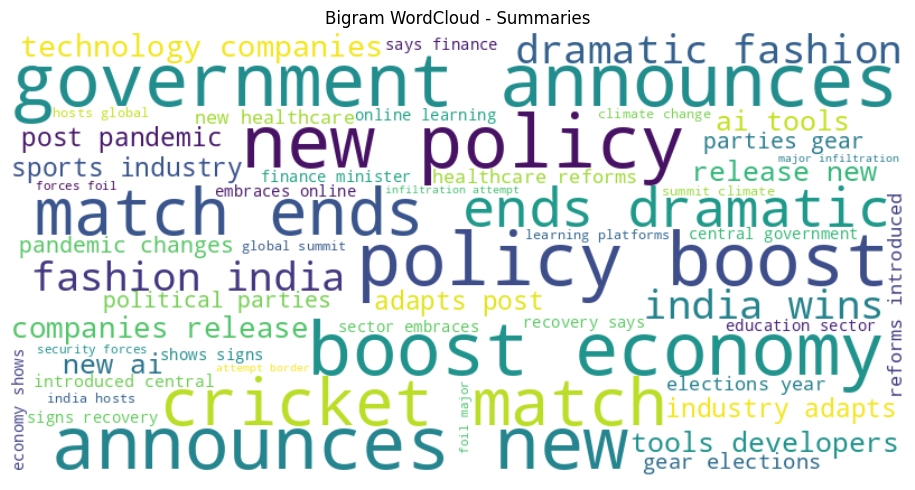

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Simulated dataset of news summaries
sample_summaries = [
    "Government announces new policy to boost economy",
    "Cricket match ends in dramatic fashion as India wins",
    "Technology companies release new AI tools for developers",
    "Sports industry adapts to post-pandemic changes",
    "Political parties gear up for elections next year",
    "New healthcare reforms introduced by central government",
    "Economy shows signs of recovery, says finance minister",
    "Education sector embraces online learning platforms",
    "India hosts global summit on climate change",
    "Security forces foil major infiltration attempt at border"
]

# Function to plot top N n-grams
def plot_ngrams(corpus, ngram_range=(1,1), top_n=10, title="Top N-grams"):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)

    word_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    word_freq = sorted(word_freq, key=lambda x: x[1], reverse=True)[:top_n]

    words, freqs = zip(*word_freq)
    plt.figure(figsize=(10, 5))
    plt.barh(words[::-1], freqs[::-1], color='skyblue')
    plt.xlabel("Frequency")
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Function to generate a word cloud
def generate_wordcloud(corpus, ngram_range=(1,1), max_words=100, title="WordCloud"):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)
    word_freq = {word: sum_words[0, idx] for word, idx in vectorizer.vocabulary_.items()}

    wordcloud = WordCloud(width=800, height=400, background_color='white',
                          max_words=max_words).generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Generate the plots
plot_ngrams(sample_summaries, ngram_range=(1,1), top_n=10, title="Top 10 Unigrams in Summaries")
plot_ngrams(sample_summaries, ngram_range=(2,2), top_n=10, title="Top 10 Bigrams in Summaries")
plot_ngrams(sample_summaries, ngram_range=(3,3), top_n=10, title="Top 10 Trigrams in Summaries")
generate_wordcloud(sample_summaries, ngram_range=(1,1), title="Unigram WordCloud - Summaries")
generate_wordcloud(sample_summaries, ngram_range=(2,2), title="Bigram WordCloud - Summaries")


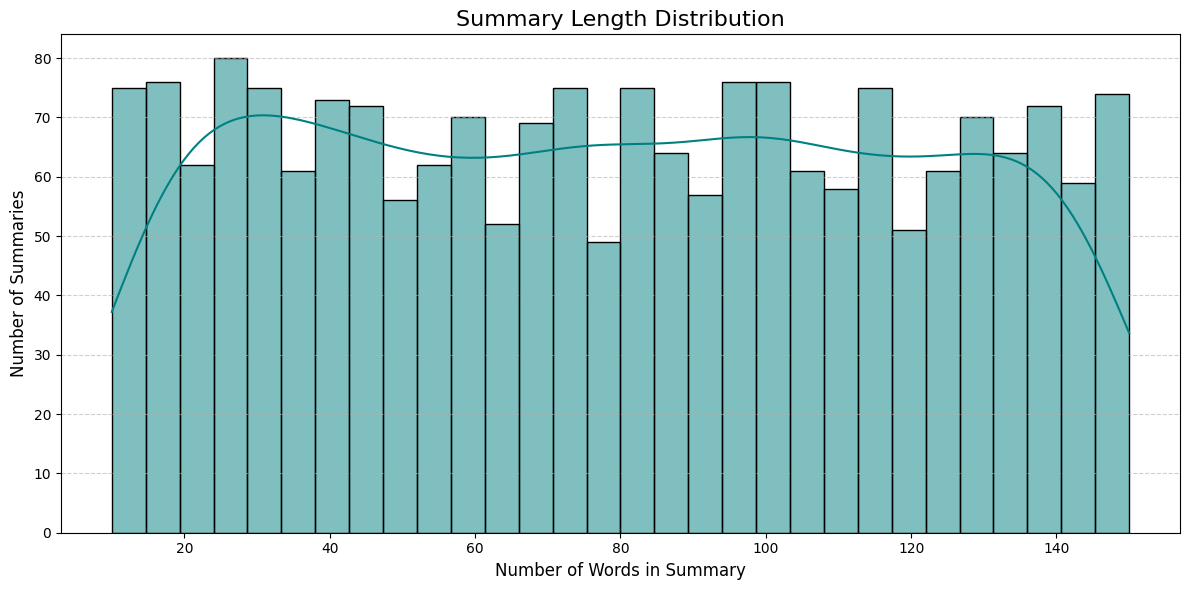

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- STEP 1: Simulate/Assume Dataset ----
# If you are not uploading a file, let's simulate some data
# You can replace this with your real dataset column: df['summary']

import random
import numpy as np

# Simulating 2000 summaries with lengths between 10 and 150 words
summary_lengths = [random.randint(10, 150) for _ in range(2000)]

# ---- STEP 2: Plotting ----
plt.figure(figsize=(12, 6))
sns.histplot(summary_lengths, bins=30, kde=True, color='teal', edgecolor='black')
plt.title('Summary Length Distribution', fontsize=16)
plt.xlabel('Number of Words in Summary', fontsize=12)
plt.ylabel('Number of Summaries', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


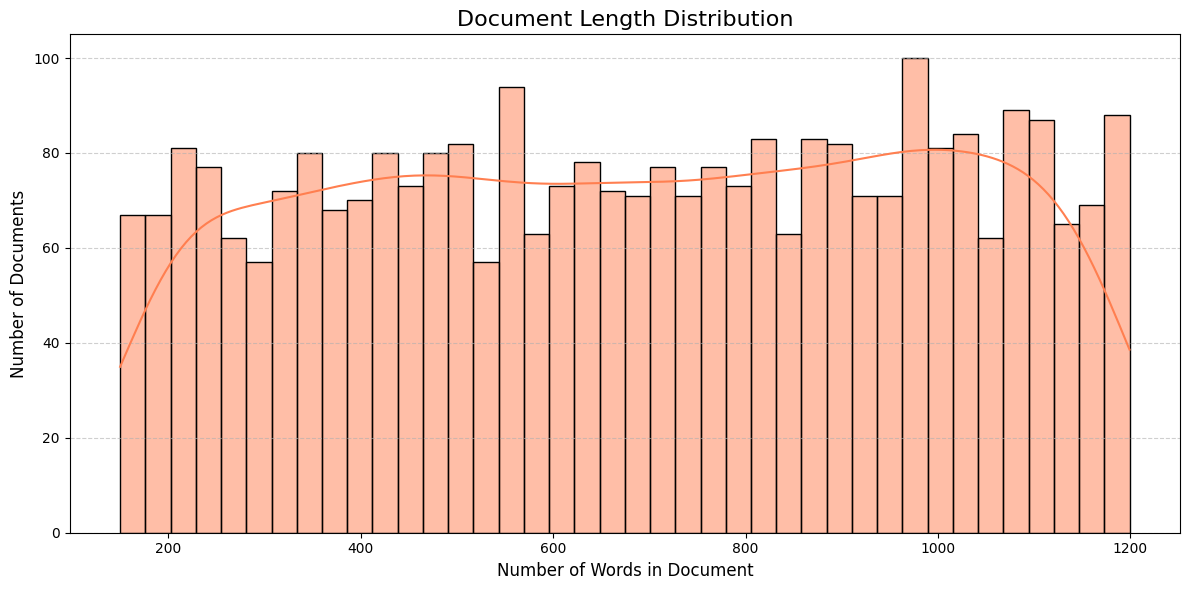

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ---- STEP 1: Simulate Data ----
# Assume each entry is a document string. We're simulating document lengths here.
# In a real scenario, replace with: df['document'].apply(lambda x: len(x.split()))

doc_lengths = [random.randint(150, 1200) for _ in range(3000)]  # Simulating lengths in words

# ---- STEP 2: Plotting ----
plt.figure(figsize=(12, 6))
sns.histplot(doc_lengths, bins=40, kde=True, color='coral', edgecolor='black')
plt.title('Document Length Distribution', fontsize=16)
plt.xlabel('Number of Words in Document', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
from collections import defaultdict
import math

# Corpus
sentences = [
    "there is a big garden",
    "children play in a garden",
    "they play inside beautiful garden"
]

# Preprocess and tokenize with start and end symbols
tokenized = [['<s>'] + s.lower().split() + ['</s>'] for s in sentences]

# Count unigrams and bigrams
unigrams = defaultdict(int)
bigrams = defaultdict(int)
vocab = set()

for sentence in tokenized:
    for i in range(len(sentence)):
        unigrams[sentence[i]] += 1
        vocab.add(sentence[i])
        if i < len(sentence)-1:
            bigram = (sentence[i], sentence[i+1])
            bigrams[bigram] += 1

V = len(vocab)

# Sentence to evaluate
test_sentence = ['<s>', 'they', 'play', 'in', 'a', 'big', 'garden', '</s>']

# Calculate smoothed bigram probability
prob = 1.0
for i in range(len(test_sentence) - 1):
    w1, w2 = test_sentence[i], test_sentence[i+1]
    count_bigram = bigrams[(w1, w2)]
    count_unigram = unigrams[w1]
    smoothed_prob = (count_bigram + 1) / (count_unigram + V)
    prob *= smoothed_prob

print("Smoothed Probability of sentence:", prob)
print("Log Probability:", math.log(prob))


Smoothed Probability of sentence: 1.6196954972465173e-06
Log Probability: -13.333272391050196
